# Building Up Longitudinal Train Dynamics: From One Locomotive to an $N$-Vehicle High-Fidelity LTD Simulator

This notebook is a **guided lab** for engineering students. We build intuition for **longitudinal train dynamics (LTD)** by:

- stating modeling assumptions and notation carefully,
- deriving governing equations in readable steps,
- implementing a numerical model **incrementally** in Python,
- simulating and plotting after each stage.

**Roadmap**

1. Modeling assumptions, notation, and sign conventions  
2. **Stage 1:** single locomotive (traction, braking, Davis resistance, grade, optional curvature)  
3. **Stage 2:** locomotive + one car, linear spring–damper coupler (no slack)  
4. **Stage 3:** nonlinear coupler with slack and asymmetric buff/draft stiffness/damping  
5. **Stage 4:** three bodies (explicit front-coupler-in / rear-coupler-out structure)  
6. **Stage 5:** general $N$-vehicle consist with dataclasses and indexed assembly  
7. **Stage 6:** route-dependent forces (grade—and optional curvature—at **each** vehicle)  
8. **Stage 7:** first-order brake buildup and a simple traction/power limit  
9. **Stage 8:** what “high fidelity” adds (discussion + future hooks)  
10. **Stage 9:** refactor toward `simulate_train(...)` and `plot_train_results(...)`  
11. **Wrap-up:** summary and suggested next steps  

**Tools:** Python with `numpy`, `scipy.integrate.solve_ivp`, `matplotlib`, `dataclasses`, and `typing` only.


In [1]:
# Tunable plotting (matplotlib only; no seaborn)
from __future__ import annotations

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple

G_MPS2 = 9.81

plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)

RNG = np.random.default_rng(7)


def _ltd_figure_output_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "notebooks").is_dir():
        out = cwd / "notebooks" / "notebook_images"
    else:
        out = cwd / "notebook_images"
    out.mkdir(parents=True, exist_ok=True)
    return out


LTD_FIGURE_DIR = _ltd_figure_output_dir()


def save_ltd_figure(fig, stem: str, dpi: int = 150) -> Path:
    """Write ``ltd_<stem>.png`` under ``notebooks/notebook_images`` (or ``./notebook_images`` if cwd is ``notebooks/``)."""
    path = LTD_FIGURE_DIR / f"ltd_{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path


## Modeling assumptions and notation

We use a **1D longitudinal** model along the **track centerline** (arc length). Each vehicle is a **point mass** at a longitudinal reference.

### State variables (vehicle $i$)

- $x_i(t)$: position along the track [m], increasing in the direction of travel  
- $v_i(t)=\dot{x}_i$: velocity [m/s]  
- $m_i$: mass [kg]  

**Ordering:** $i=0$ is the **lead** vehicle (locomotive by default). Vehicle $i+1$ is **behind** $i$, so typically $x_i > x_{i+1}$ in steady spacing.

### Coupler kinematics (between $i$ in front and $i+1$)

With nominal spacing $L_{0,i}$ [m], define **extension** (positive in **draft/tension**):

$$
\delta_i = (x_i - x_{i+1}) - L_{0,i}, \qquad \dot{\delta}_i = v_i - v_{i+1}.
$$

### Force balance (schematic)

$$
m_i \dot{v}_i = F_{\mathrm{trac},i} - F_{\mathrm{brk},i} - R_i(v_i) - G_i(x_i) - C_i(x_i,v_i) + F_{\mathrm{cpl,in},i} - F_{\mathrm{cpl,out},i}.
$$

- $R$: Davis-style running resistance (opposes motion)  
- $G$: grade resistance from local inclination  
- $C$: optional curvature proxy  

### Davis resistance (longitudinal)

Magnitude $|R| \approx A + B|v| + C v^2$. Longitudinal component (opposes motion):

$$
R_{\mathrm{long}}(v)=\big(A+B|v|+Cv^2\big)\operatorname{sgn}(v).
$$

### Grade

$G(x)\approx m g\sin\theta(x)$ with $\theta$ from the local track.

### Sign conventions

- Positive traction pulls forward.  
- **$F_j$** (coupler $j$ between $j$ and $j+1$) is the force **on the rear vehicle** $j+1$ along $+x$. Vehicle $j$ feels **$-F_j$**.

**What this means physically:** couplers transmit push–pull; slack and nonlinear stiffness create impulsive take-up transients.

### Implementation notes (global)

- Time integration: `scipy.integrate.solve_ivp`.  
- Stiff couplers $\Rightarrow$ stiff ODEs; try `method="Radau"` if `RK45` struggles.

### Next extension

- Validate signs on a 1-DOF case before adding cars.


### Common pitfalls, stiffness, plausibility

**Sign mistakes:** resistance must oppose motion; coupler $F$ on the rear car is positive in draft (front pulls rear forward); the lead feels $-F$.

**Numerical stiffness:** high $k$ and moderate $c$ $\Rightarrow$ fast oscillations and small effective step sizes. Watch `success`, warnings, and nonphysical growth.

**Plausibility:** coupler forces in a believable range; coasting on flat track slows down; climbing grade opposes motion; traction at the lead eventually pulls trailing mass (with lag if slack exists).


## Stage 1 — Single locomotive

$$
\dot{x}=v, \qquad m\dot{v}=F_{\mathrm{trac}}-F_{\mathrm{brk}}-R(v)-G(x)-C(x,v).
$$

**What this means physically:** verify the integrator and force balance before adding couplers.

### Implementation notes

State $\mathbf{y}=[x,v]^T$. Smooth traction ramp in time.

### Next extension

Two bodies + coupler (Stage 2).


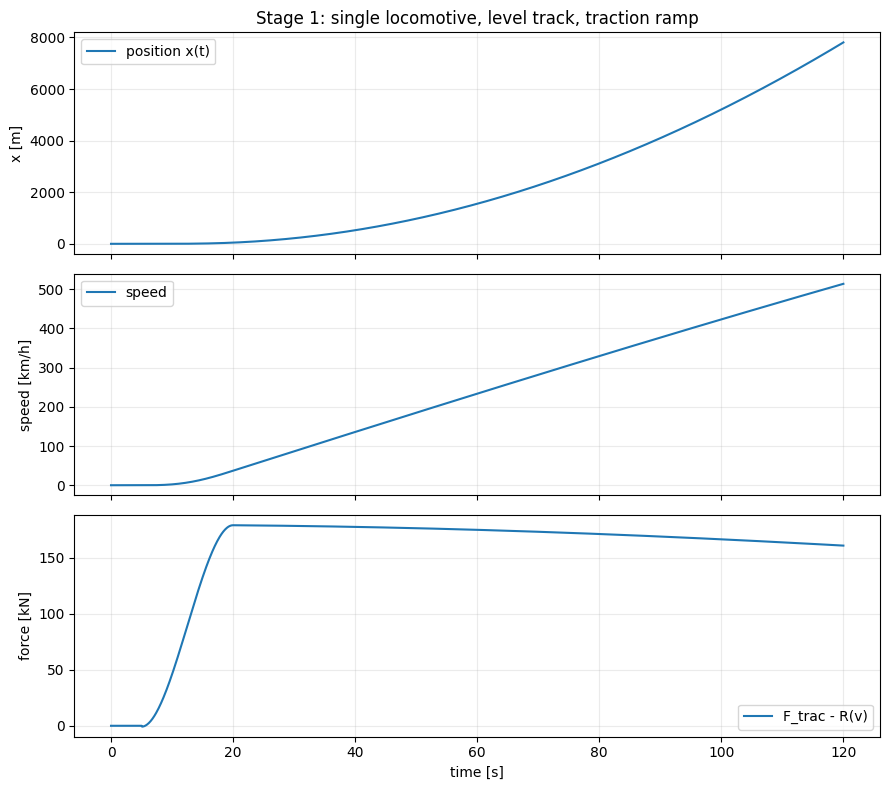

Stage 1 sanity: final speed (m/s) = 142.62615005970446


In [5]:
# --- Stage 1 parameters (tunable; illustrative / not calibrated) ---
M_LOCO_KG = 130_000.0
DAVIS_A = 800.0
DAVIS_B = 15.0
DAVIS_C = 0.8


def davis_resistance_longitudinal(v, A: float, B: float, C: float) -> np.ndarray:
    """Longitudinal resistance [N] opposing motion (vectorized)."""
    v = np.asarray(v, dtype=float)
    sgn = np.where(np.abs(v) < 1e-9, 0.0, np.sign(v))
    mag = A + B * np.abs(v) + C * v * v
    return mag * sgn


def grade_force(m_kg: float, x_m: float, theta_at_x: Callable[[float], float]) -> float:
    """Grade resistance G = m g sin(theta(x)); theta in radians."""
    th = float(theta_at_x(x_m))
    return m_kg * G_MPS2 * np.sin(th)


def stage1_rhs(
    t: float,
    y: np.ndarray,
    m_kg: float,
    F_trac_fn: Callable[[float], float],
    F_brk_fn: Callable[[float], float],
    theta_at_x: Callable[[float], float],
    kappa_at_x: Callable[[float], float],
    davis: Tuple[float, float, float],
    k_curv_scale: float,
) -> np.ndarray:
    x, v = float(y[0]), float(y[1])
    F_trac = float(F_trac_fn(t))
    F_brk = float(F_brk_fn(t))
    R = davis_resistance_longitudinal(v, *davis)
    G = grade_force(m_kg, x, theta_at_x)
    kap = float(kappa_at_x(x))
    Cmag = k_curv_scale * m_kg * v * v * abs(kap)
    C = 0.0 if abs(v) < 1e-9 else Cmag * np.sign(v)
    dv = (F_trac - F_brk - R - G - C) / m_kg
    return np.array([v, dv], dtype=float)


def flat_theta(x: float) -> float:
    return 0.0


def zero_kappa(x: float) -> float:
    return 0.0


def traction_ramp(
    t: float, t0: float = 5.0, t1: float = 20.0, F_max: float = 180_000.0
) -> float:
    if t < t0:
        return 0.0
    if t > t1:
        return F_max
    u = (t - t0) / (t1 - t0)
    return F_max * (3 * u * u - 2 * u * u * u)


def brake_zero(t: float) -> float:
    return 0.0


y0 = np.array([0.0, 0.0], dtype=float)
t_span = (0.0, 120.0)
t_eval = np.linspace(t_span[0], t_span[1], 1201)

sol1 = solve_ivp(
    fun=lambda t, y: stage1_rhs(
        t,
        y,
        M_LOCO_KG,
        traction_ramp,
        brake_zero,
        flat_theta,
        zero_kappa,
        (DAVIS_A, DAVIS_B, DAVIS_C),
        k_curv_scale=0.0,
    ),
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    rtol=1e-7,
    atol=1e-9,
)
assert sol1.success, sol1.message
x1, v1 = sol1.y[0], sol1.y[1]
F_trac_hist = np.array([traction_ramp(float(t)) for t in sol1.t])
R_hist = davis_resistance_longitudinal(v1, DAVIS_A, DAVIS_B, DAVIS_C)
net_F = F_trac_hist - R_hist

fig, ax = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
ax[0].plot(sol1.t, x1, label="position x(t)")
ax[0].set_ylabel("x [m]")
ax[0].set_title("Stage 1: single locomotive, level track, traction ramp")
ax[0].legend()

ax[1].plot(sol1.t, v1 * 3.6, label="speed")
ax[1].set_ylabel("speed [km/h]")
ax[1].legend()

ax[2].plot(sol1.t, net_F / 1e3, label="F_trac - R(v)")
ax[2].set_ylabel("force [kN]")
ax[2].set_xlabel("time [s]")
ax[2].legend()
plt.tight_layout()
save_ltd_figure(fig, "stage01_single_loco_traction_ramp_position_speed_netforce")
plt.show()

print("Stage 1 sanity: final speed (m/s) =", float(v1[-1]))



#### Interpretation (Stage 1)

You should see speed rise as the **smooth traction ramp** wins over **Davis resistance** (which grows with speed). Here, commanded traction remains large enough that **equilibrium speed is not reached inside 120 s**, so speed keeps climbing—useful to verify the integrator, but not a steady-state operating point. **Stage 7** adds a simple **power limit** so traction cannot grow without bound at low speed. All masses and Davis coefficients are **illustrative**, not calibrated.

### Sanity check (Stage 1)

Run after the integration: state dimension should be 2; on flat track with no traction, speed should decay toward 0 from resistance.


In [6]:
assert sol1.y.shape[0] == 2
print("y shape:", sol1.y.shape, "t points:", len(sol1.t))



y shape: (2, 1201) t points: 1201


## Stage 2 — Locomotive + one car (linear coupler, no slack)

Coupler force on the rear car:

$$
F = k\delta + c\dot{\delta}, \quad \delta=(x_0-x_1)-L_0, \quad \dot{\delta}=v_0-v_1.
$$

$$
m_0\dot{v}_0 = F_{\mathrm{trac}}-F_{\mathrm{brk,0}}-R_0-G_0-F,\quad
m_1\dot{v}_1 = -F_{\mathrm{brk,1}}-R_1-G_1+F.
$$

**What this means physically:** force transmission and transient lag between ends.

### Implementation notes

$\mathbf{y}=[x_0,x_1,v_0,v_1]^T$. Initialize spacing so $\delta(0)$ matches intent.

### Next extension

Slack + asymmetric buff/draft (Stage 3).


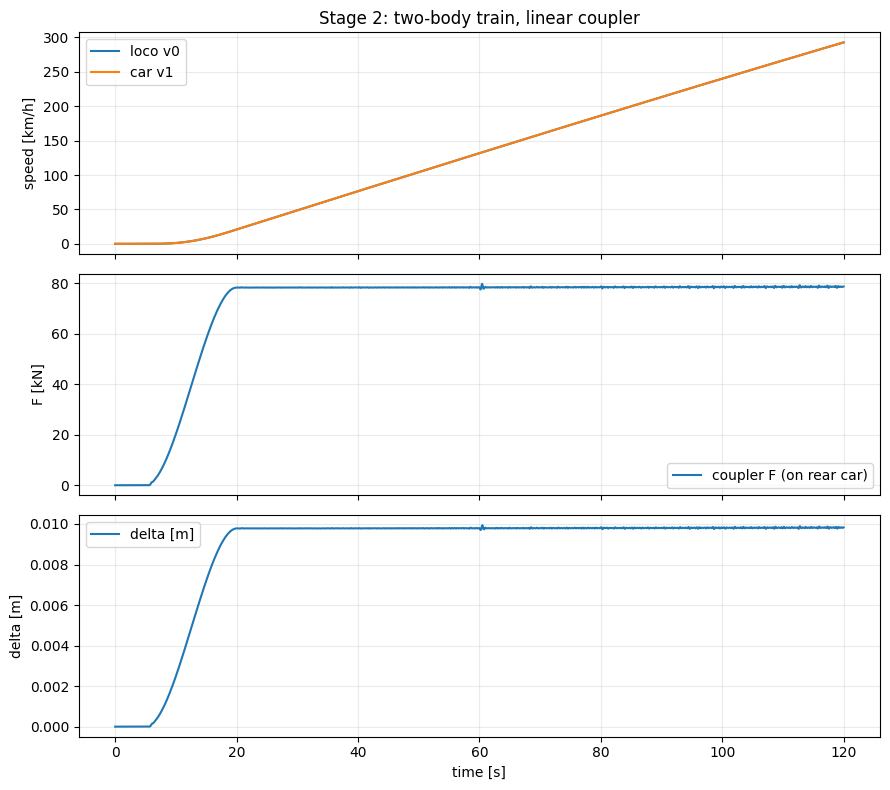

max |F| (MN): 0.07973758893333524


In [7]:
# --- Stage 2 parameters (tunable) ---
M_CAR_KG = 100_000.0
L0 = 20.0
K_CPL = 8.0e6
C_CPL = 4.0e5
DAVIS_A_CAR = 600.0
DAVIS_B_CAR = 12.0
DAVIS_C_CAR = 0.7


def stage2_rhs(
    t: float,
    y: np.ndarray,
    L0_: float,
    k: float,
    c: float,
    m0: float,
    m1: float,
    F_trac_fn: Callable[[float], float],
    F_brk0_fn: Callable[[float], float],
    F_brk1_fn: Callable[[float], float],
    theta_at_x: Callable[[float], float],
) -> np.ndarray:
    x0, x1, v0, v1 = map(float, y)
    dlt = (x0 - x1) - L0_
    dlt_dot = v0 - v1
    F = k * dlt + c * dlt_dot
    R0 = davis_resistance_longitudinal(v0, DAVIS_A, DAVIS_B, DAVIS_C)
    R1 = davis_resistance_longitudinal(v1, DAVIS_A_CAR, DAVIS_B_CAR, DAVIS_C_CAR)
    dv0 = (F_trac_fn(t) - F_brk0_fn(t) - R0 - grade_force(m0, x0, theta_at_x) - F) / m0
    dv1 = (-F_brk1_fn(t) - R1 - grade_force(m1, x1, theta_at_x) + F) / m1
    return np.array([v0, v1, dv0, dv1], dtype=float)


x0_0, x1_0 = 100.0, 100.0 - L0
y0_2 = np.array([x0_0, x1_0, 0.0, 0.0], dtype=float)

sol2 = solve_ivp(
    fun=lambda t, y: stage2_rhs(
        t,
        y,
        L0,
        K_CPL,
        C_CPL,
        M_LOCO_KG,
        M_CAR_KG,
        traction_ramp,
        brake_zero,
        brake_zero,
        flat_theta,
    ),
    t_span=(0.0, 120.0),
    y0=y0_2,
    t_eval=np.linspace(0.0, 120.0, 2401),
    rtol=1e-6,
    atol=1e-8,
)
assert sol2.success, sol2.message
x0t, x1t, v0t, v1t = sol2.y
delta = (x0t - x1t) - L0
dlt_dot = v0t - v1t
F_coupler = K_CPL * delta + C_CPL * dlt_dot

fig, ax = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
ax[0].plot(sol2.t, v0t * 3.6, label="loco v0")
ax[0].plot(sol2.t, v1t * 3.6, label="car v1")
ax[0].set_ylabel("speed [km/h]")
ax[0].set_title("Stage 2: two-body train, linear coupler")
ax[0].legend()

ax[1].plot(sol2.t, F_coupler / 1e3, label="coupler F (on rear car)")
ax[1].set_ylabel("F [kN]")
ax[1].legend()

ax[2].plot(sol2.t, delta, label="delta [m]")
ax[2].set_ylabel("delta [m]")
ax[2].set_xlabel("time [s]")
ax[2].legend()
plt.tight_layout()
save_ltd_figure(fig, "stage02_loco_car_speeds_coupler_force_extension")
plt.show()

print("max |F| (MN):", float(np.max(np.abs(F_coupler))) / 1e6)



#### Interpretation (Stage 2)

The **rear car lags** the locomotive briefly: the coupler must stretch (positive $\delta$ in draft) to transmit tension. Damping dissipates oscillations. If forces look enormous, reduce `K_CPL` or increase `C_CPL`—stiff couplers are numerically harsh.

## Stage 3 — Nonlinear coupler: slack + asymmetric buff/draft

Inside deadband $|\delta|\le s$, $F=0$. Outside, use different $(k,c)$ for draft ($\delta>s$) and buff ($\delta<-s$) on over-travel beyond slack.

This is a **simplified proxy** for draft gear, not a calibrated hysteresis model.

### What this means physically

Slack take-up can produce sharp force pulses.

### Implementation notes

Optional future hysteresis: add internal state per coupler (Bouc–Wen, etc.).

### Next extension

Three bodies (Stage 4).


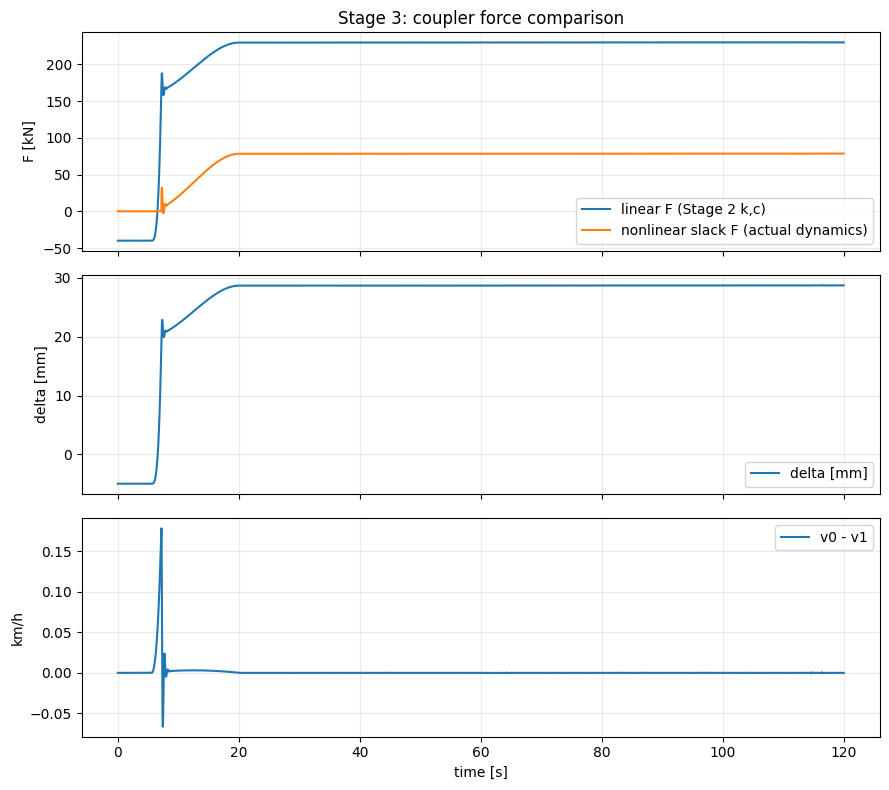

In [8]:
def coupler_force_slack_asymmetric(delta, delta_dot, slack_half, k_draft, c_draft, k_buff, c_buff):
    """Force on rear car; vectorized."""
    delta = np.asarray(delta, float)
    delta_dot = np.asarray(delta_dot, float)
    s = float(slack_half)
    F = np.zeros_like(delta)
    mask_d = delta > s
    e_d = delta[mask_d] - s
    F[mask_d] = k_draft * e_d + c_draft * delta_dot[mask_d]
    mask_b = delta < -s
    e_b = delta[mask_b] + s
    F[mask_b] = k_buff * e_b + c_buff * delta_dot[mask_b]
    return F


SLACK_HALF = 0.02
K_DRAFT, C_DRAFT = 9.0e6, 5.0e5
K_BUFF, C_BUFF = 12.0e6, 7.0e5


def stage2_rhs_nonlinear(t: float, y: np.ndarray) -> np.ndarray:
    x0, x1, v0, v1 = map(float, y)
    dlt = (x0 - x1) - L0
    dlt_dot = v0 - v1
    F = float(
        coupler_force_slack_asymmetric(
            np.array([dlt]), np.array([dlt_dot]), SLACK_HALF, K_DRAFT, C_DRAFT, K_BUFF, C_BUFF
        )[0]
    )
    R0 = davis_resistance_longitudinal(v0, DAVIS_A, DAVIS_B, DAVIS_C)
    R1 = davis_resistance_longitudinal(v1, DAVIS_A_CAR, DAVIS_B_CAR, DAVIS_C_CAR)
    dv0 = (traction_ramp(t) - R0 - F) / M_LOCO_KG
    dv1 = (-R1 + F) / M_CAR_KG
    return np.array([v0, v1, dv0, dv1], dtype=float)


x0_0n, x1_0n = 100.0, 100.0 - L0 + 0.005
y0_2n = np.array([x0_0n, x1_0n, 0.0, 0.0], dtype=float)

sol2n = solve_ivp(
    stage2_rhs_nonlinear,
    (0.0, 120.0),
    y0_2n,
    t_eval=np.linspace(0.0, 120.0, 4001),
    rtol=1e-7,
    atol=1e-9,
)
assert sol2n.success, sol2n.message
x0n, x1n, v0n, v1n = sol2n.y
dlt_n = (x0n - x1n) - L0
dlt_dn = v0n - v1n
F_lin = K_CPL * dlt_n + C_CPL * dlt_dn
F_nl = coupler_force_slack_asymmetric(dlt_n, dlt_dn, SLACK_HALF, K_DRAFT, C_DRAFT, K_BUFF, C_BUFF)

fig, ax = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
ax[0].plot(sol2n.t, F_lin / 1e3, label="linear F (Stage 2 k,c)")
ax[0].plot(sol2n.t, F_nl / 1e3, label="nonlinear slack F (actual dynamics)")
ax[0].set_ylabel("F [kN]")
ax[0].set_title("Stage 3: coupler force comparison")
ax[0].legend()

ax[1].plot(sol2n.t, dlt_n * 1000.0, label="delta [mm]")
ax[1].set_ylabel("delta [mm]")
ax[1].legend()

ax[2].plot(sol2n.t, (v0n - v1n) * 3.6, label="v0 - v1")
ax[2].set_ylabel("km/h")
ax[2].set_xlabel("time [s]")
ax[2].legend()
plt.tight_layout()
save_ltd_figure(fig, "stage03_slack_coupler_linear_vs_nonlinear_force_delta_speeddiff")
plt.show()



#### Interpretation (Stage 3)

Compare the **linear** force trace (what the same extension would produce with Stage-2 parameters) to the **actual nonlinear** dynamics: slack creates periods of **near-zero force** inside the deadband, then sharper loading when metal contacts engage. This is why slack models matter for impact-style longitudinal loads.

## Stage 4 — Three bodies (loco + two cars)

Couplers $F_0$ (0–1) and $F_1$ (1–2), each defined as force **on the rear** car.

$$
m_0\dot{v}_0 = F_{\mathrm{trac}}-R_0-G_0-F_0,\quad
m_1\dot{v}_1 = -R_1-G_1+F_0-F_1,\quad
m_2\dot{v}_2 = -R_2-G_2+F_1.
$$

**Front-in minus rear-out** on car 1: $+F_0-F_1$.

### Next extension

Indexed $N$-vehicle assembly (Stage 5).


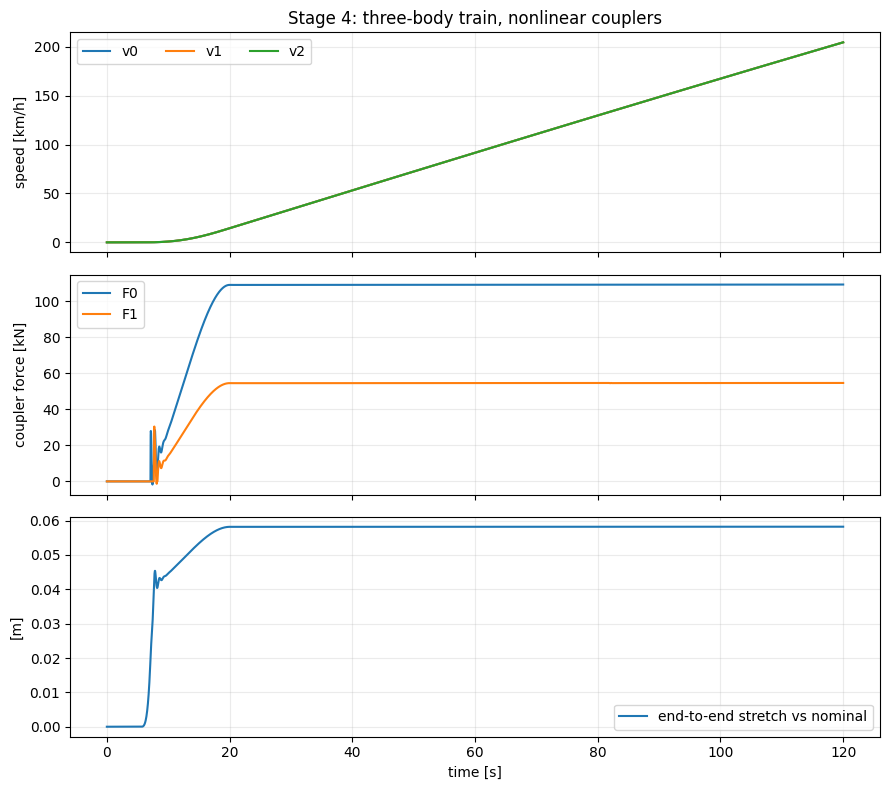

In [9]:
L0_list = [20.0, 20.0]


def coupler_pair_force(delta: float, ddelta: float) -> float:
    return float(
        coupler_force_slack_asymmetric(
            np.array([delta]),
            np.array([ddelta]),
            SLACK_HALF,
            K_DRAFT,
            C_DRAFT,
            K_BUFF,
            C_BUFF,
        )[0]
    )


def stage4_rhs(
    t: float,
    y: np.ndarray,
    m: np.ndarray,
    L0s: Sequence[float],
    F_trac_fn: Callable[[float], float],
    theta_at_x: Callable[[float], float],
) -> np.ndarray:
    x = y[0:3]
    v = y[3:6]
    d0 = (x[0] - x[1]) - L0s[0]
    d1 = (x[1] - x[2]) - L0s[1]
    dd0 = v[0] - v[1]
    dd1 = v[1] - v[2]
    F0 = coupler_pair_force(float(d0), float(dd0))
    F1 = coupler_pair_force(float(d1), float(dd1))
    davis_loco = (DAVIS_A, DAVIS_B, DAVIS_C)
    davis_car = (DAVIS_A_CAR, DAVIS_B_CAR, DAVIS_C_CAR)
    R = np.array(
        [
            davis_resistance_longitudinal(v[0], *davis_loco),
            davis_resistance_longitudinal(v[1], *davis_car),
            davis_resistance_longitudinal(v[2], *davis_car),
        ]
    )
    G = np.array([grade_force(float(m[i]), float(x[i]), theta_at_x) for i in range(3)])
    dv0 = (F_trac_fn(t) - R[0] - G[0] - F0) / m[0]
    dv1 = (-R[1] - G[1] + F0 - F1) / m[1]
    dv2 = (-R[2] - G[2] + F1) / m[2]
    return np.array([v[0], v[1], v[2], dv0, dv1, dv2], dtype=float)


M3 = np.array([M_LOCO_KG, M_CAR_KG, M_CAR_KG], dtype=float)
x_init = np.array(
    [200.0, 200.0 - L0_list[0], 200.0 - L0_list[0] - L0_list[1]], dtype=float
)
y0_4 = np.concatenate([x_init, np.zeros(3)])

sol4 = solve_ivp(
    fun=lambda t, y: stage4_rhs(t, y, M3, L0_list, traction_ramp, flat_theta),
    t_span=(0.0, 120.0),
    y0=y0_4,
    t_eval=np.linspace(0.0, 120.0, 4001),
    rtol=1e-7,
    atol=1e-9,
)
assert sol4.success, sol4.message
X = sol4.y[0:3]
V = sol4.y[3:6]
d0h = (X[0] - X[1]) - L0_list[0]
d1h = (X[1] - X[2]) - L0_list[1]
F0h = coupler_force_slack_asymmetric(d0h, V[0] - V[1], SLACK_HALF, K_DRAFT, C_DRAFT, K_BUFF, C_BUFF)
F1h = coupler_force_slack_asymmetric(d1h, V[1] - V[2], SLACK_HALF, K_DRAFT, C_DRAFT, K_BUFF, C_BUFF)

fig, ax = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
ax[0].plot(sol4.t, V.T * 3.6, label=["v0", "v1", "v2"])
ax[0].set_ylabel("speed [km/h]")
ax[0].set_title("Stage 4: three-body train, nonlinear couplers")
ax[0].legend(ncol=3)

ax[1].plot(sol4.t, F0h / 1e3, label="F0")
ax[1].plot(sol4.t, F1h / 1e3, label="F1")
ax[1].set_ylabel("coupler force [kN]")
ax[1].legend()

stretch = (X[0] - X[2]) - (L0_list[0] + L0_list[1])
ax[2].plot(sol4.t, stretch, label="end-to-end stretch vs nominal")
ax[2].set_ylabel("[m]")
ax[2].set_xlabel("time [s]")
ax[2].legend()
plt.tight_layout()
save_ltd_figure(fig, "stage04_three_body_speeds_coupler_forces_train_stretch")
plt.show()



#### Interpretation (Stage 4)

The **last car** is slowest to respond: coupler forces propagate sequentially. End-to-end **stretch** shows how the consist elongates in draft during traction. Optional: run the next cell for a **service brake** on the lead only to see how braking redistributes coupler loads.

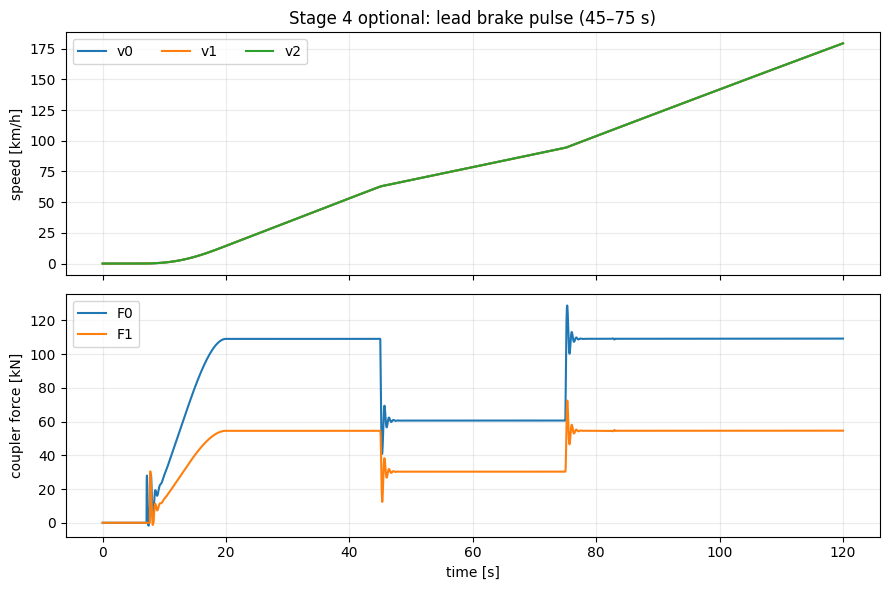

In [10]:
# Optional scenario: lead-only service brake pulse (same three-body model)


def brake_lead_only(t: float) -> float:
    return 80_000.0 if 45.0 < t < 75.0 else 0.0


def stage4_rhs_brake(
    t: float,
    y: np.ndarray,
    m: np.ndarray,
    L0s: Sequence[float],
    F_trac_fn: Callable[[float], float],
    F_brk0_fn: Callable[[float], float],
    theta_at_x: Callable[[float], float],
) -> np.ndarray:
    x = y[0:3]
    v = y[3:6]
    d0 = (x[0] - x[1]) - L0s[0]
    d1 = (x[1] - x[2]) - L0s[1]
    dd0 = v[0] - v[1]
    dd1 = v[1] - v[2]
    F0 = coupler_pair_force(float(d0), float(dd0))
    F1 = coupler_pair_force(float(d1), float(dd1))
    davis_loco = (DAVIS_A, DAVIS_B, DAVIS_C)
    davis_car = (DAVIS_A_CAR, DAVIS_B_CAR, DAVIS_C_CAR)
    R = np.array(
        [
            davis_resistance_longitudinal(v[0], *davis_loco),
            davis_resistance_longitudinal(v[1], *davis_car),
            davis_resistance_longitudinal(v[2], *davis_car),
        ]
    )
    G = np.array([grade_force(float(m[i]), float(x[i]), theta_at_x) for i in range(3)])
    Fb0 = float(F_brk0_fn(t))
    dv0 = (F_trac_fn(t) - Fb0 - R[0] - G[0] - F0) / m[0]
    dv1 = (-R[1] - G[1] + F0 - F1) / m[1]
    dv2 = (-R[2] - G[2] + F1) / m[2]
    return np.array([v[0], v[1], v[2], dv0, dv1, dv2], dtype=float)


sol4b = solve_ivp(
    fun=lambda t, y: stage4_rhs_brake(t, y, M3, L0_list, traction_ramp, brake_lead_only, flat_theta),
    t_span=(0.0, 120.0),
    y0=y0_4,
    t_eval=np.linspace(0.0, 120.0, 4001),
    rtol=1e-7,
    atol=1e-9,
)
assert sol4b.success, sol4b.message
Vb = sol4b.y[3:6]

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].plot(sol4b.t, Vb.T * 3.6, label=["v0", "v1", "v2"])
ax[0].set_ylabel("speed [km/h]")
ax[0].set_title("Stage 4 optional: lead brake pulse (45–75 s)")
ax[0].legend(ncol=3)

d0b = (sol4b.y[0] - sol4b.y[1]) - L0_list[0]
d1b = (sol4b.y[1] - sol4b.y[2]) - L0_list[1]
F0b = coupler_force_slack_asymmetric(
    d0b, sol4b.y[3] - sol4b.y[4], SLACK_HALF, K_DRAFT, C_DRAFT, K_BUFF, C_BUFF
)
F1b = coupler_force_slack_asymmetric(
    d1b, sol4b.y[4] - sol4b.y[5], SLACK_HALF, K_DRAFT, C_DRAFT, K_BUFF, C_BUFF
)
ax[1].plot(sol4b.t, F0b / 1e3, label="F0")
ax[1].plot(sol4b.t, F1b / 1e3, label="F1")
ax[1].set_ylabel("coupler force [kN]")
ax[1].set_xlabel("time [s]")
ax[1].legend()
plt.tight_layout()
save_ltd_figure(fig, "stage04b_lead_brake_pulse_speeds_coupler_forces")
plt.show()

## Stage 5 — General $N$-vehicle consist

**State (documented):**

$$
\mathbf{y}=[x_0,\ldots,x_{N-1},\,v_0,\ldots,v_{N-1}]^T\in\mathbb{R}^{2N}.
$$

**Couplers** $j=0\ldots N-2$: $\delta_j=(x_j-x_{j+1})-L_{0,j}$, $F_j=f_j(\delta_j,\dot{\delta}_j)$ on the rear car.

**Dynamics:**

$$
m_i\dot{v}_i = F_{\mathrm{trac},i}-F_{\mathrm{brk},i}-R_i-G_i-C_i + (F_{i-1}\text{ if }i>0) - (F_i\text{ if }i<N-1).
$$

`VehicleParameters` / `CouplerParameters` / `RouteProfile` structure the data for reuse and future calibration.

### What this means physically

Cost per RHS evaluation scales $\mathcal{O}(N)$. Long trains can show pronounced longitudinal oscillations.

### Next extension

Per-vehicle grade from a route profile (Stage 6).


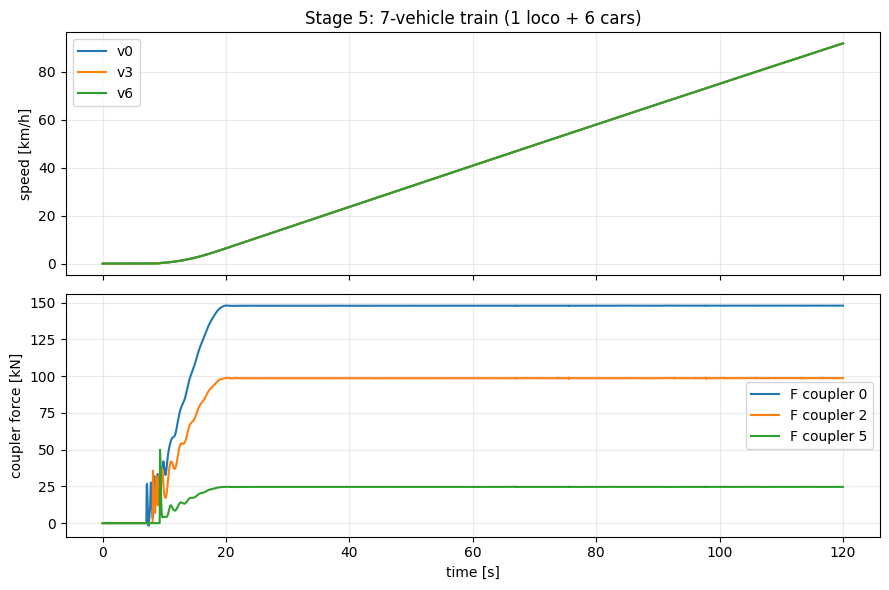

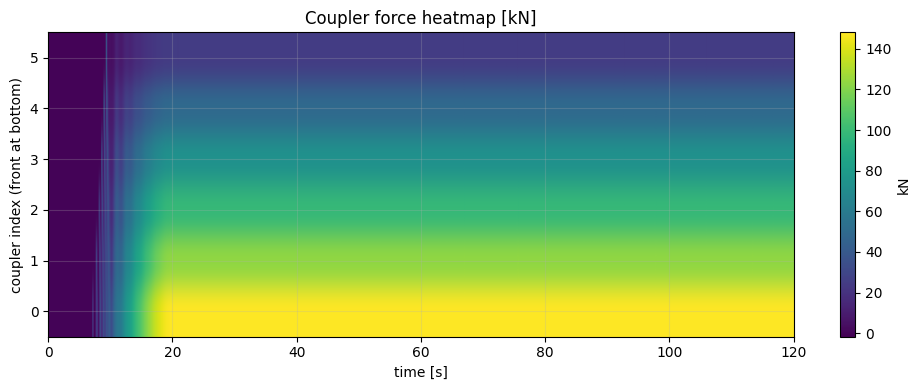

State dim 2N = 14 coupler count = 6


In [11]:
@dataclass
class VehicleParameters:
    mass_kg: float
    davis_A: float
    davis_B: float
    davis_C: float
    can_traction: bool = False
    F_trac_max_N: float = 0.0
    F_brk_max_N: float = 250_000.0


@dataclass
class CouplerParameters:
    L0_m: float
    slack_half_m: float
    k_draft: float
    c_draft: float
    k_buff: float
    c_buff: float


@dataclass
class RouteProfile:
    """Piecewise-linear sin(theta(x)) and optional kappa(x) along track."""

    s_nodes_m: np.ndarray
    sin_theta_nodes: np.ndarray
    kappa_nodes: Optional[np.ndarray] = None

    def sin_theta_at(self, x: float) -> float:
        return float(np.interp(x, self.s_nodes_m, self.sin_theta_nodes))

    def kappa_at(self, x: float) -> float:
        if self.kappa_nodes is None:
            return 0.0
        return float(np.interp(x, self.s_nodes_m, self.kappa_nodes))


def curvature_force_longitudinal(
    m_kg: float, v: float, x: float, route: RouteProfile, k_scale: float
) -> float:
    if k_scale == 0.0:
        return 0.0
    kap = route.kappa_at(x)
    mag = k_scale * m_kg * v * v * abs(kap)
    return 0.0 if abs(v) < 1e-9 else mag * np.sign(v)


def train_rhs_n(
    t: float,
    y: np.ndarray,
    vehicles: Sequence[VehicleParameters],
    couplers: Sequence[CouplerParameters],
    route: RouteProfile,
    F_trac_cmd: Callable[[float, int], float],
    F_brk_cmd: Callable[[float, int], float],
    k_curv_scale: float,
) -> np.ndarray:
    """RHS for y=[x (N), v (N)]."""
    N = len(vehicles)
    x = y[0:N]
    v = y[N : 2 * N]
    dv = np.zeros(N, dtype=float)
    F_couple = np.zeros(N - 1, dtype=float)
    for j in range(N - 1):
        c = couplers[j]
        dlt = (x[j] - x[j + 1]) - c.L0_m
        ddv = v[j] - v[j + 1]
        F_couple[j] = float(
            coupler_force_slack_asymmetric(
                np.array([dlt]),
                np.array([ddv]),
                c.slack_half_m,
                c.k_draft,
                c.c_draft,
                c.k_buff,
                c.c_buff,
            )[0]
        )
    for i in range(N):
        vp = vehicles[i]
        Fi_in = F_couple[i - 1] if i > 0 else 0.0
        Fi_out = F_couple[i] if i < N - 1 else 0.0
        R = float(davis_resistance_longitudinal(v[i], vp.davis_A, vp.davis_B, vp.davis_C))
        G = grade_force(vp.mass_kg, float(x[i]), route.sin_theta_at)
        C = curvature_force_longitudinal(vp.mass_kg, float(v[i]), float(x[i]), route, k_curv_scale)
        F_tr = min(F_trac_cmd(t, i), vp.F_trac_max_N) if vp.can_traction else 0.0
        F_tr = float(F_tr)
        F_br = min(F_brk_cmd(t, i), vp.F_brk_max_N)
        F_br = float(max(F_br, 0.0))
        dv[i] = (F_tr - F_br - R - G - C + Fi_in - Fi_out) / vp.mass_kg
    return np.concatenate([v, dv])


def make_simple_train(
    n_cars: int,
    L0_m: float = 20.0,
) -> Tuple[List[VehicleParameters], List[CouplerParameters]]:
    """One lead locomotive + n_cars freight cars."""
    loco = VehicleParameters(
        mass_kg=M_LOCO_KG,
        davis_A=DAVIS_A,
        davis_B=DAVIS_B,
        davis_C=DAVIS_C,
        can_traction=True,
        F_trac_max_N=300_000.0,
    )
    car = VehicleParameters(
        mass_kg=M_CAR_KG,
        davis_A=DAVIS_A_CAR,
        davis_B=DAVIS_B_CAR,
        davis_C=DAVIS_C_CAR,
        can_traction=False,
    )
    vehicles = [loco] + [car] * n_cars
    cp = CouplerParameters(
        L0_m=L0_m,
        slack_half_m=SLACK_HALF,
        k_draft=K_DRAFT,
        c_draft=C_DRAFT,
        k_buff=K_BUFF,
        c_buff=C_BUFF,
    )
    couplers = [cp] * (len(vehicles) - 1)
    return vehicles, couplers


def pack_y0(x0: np.ndarray, v0: np.ndarray) -> np.ndarray:
    return np.concatenate([x0, v0])


N_cars = 6
veh_N, cpl_N = make_simple_train(N_cars)
route_flat = RouteProfile(
    s_nodes_m=np.array([0.0, 50_000.0]),
    sin_theta_nodes=np.array([0.0, 0.0]),
    kappa_nodes=None,
)
N = len(veh_N)
x0_train = np.array([1000.0 - i * cpl_N[0].L0_m for i in range(N)], dtype=float)
v0_train = np.zeros(N, dtype=float)
y0_n = pack_y0(x0_train, v0_train)


def F_trac_lead_only(t: float, i: int) -> float:
    return traction_ramp(t) if i == 0 else 0.0


def F_brk_zero(t: float, i: int) -> float:
    return 0.0


sol5 = solve_ivp(
    fun=lambda t, y: train_rhs_n(
        t, y, veh_N, cpl_N, route_flat, F_trac_lead_only, F_brk_zero, k_curv_scale=0.0
    ),
    t_span=(0.0, 120.0),
    y0=y0_n,
    t_eval=np.linspace(0.0, 120.0, 2001),
    rtol=1e-6,
    atol=1e-8,
)
assert sol5.success, sol5.message
Xn = sol5.y[0:N]
Vn = sol5.y[N : 2 * N]
Fhist = np.zeros((N - 1, sol5.t.size))
for k in range(sol5.t.size):
    x = Xn[:, k]
    v = Vn[:, k]
    for j in range(N - 1):
        c = cpl_N[j]
        dlt = (x[j] - x[j + 1]) - c.L0_m
        ddv = v[j] - v[j + 1]
        Fhist[j, k] = coupler_force_slack_asymmetric(
            np.array([dlt]),
            np.array([ddv]),
            c.slack_half_m,
            c.k_draft,
            c.c_draft,
            c.k_buff,
            c.c_buff,
        )[0]

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for idx in [0, N // 2, N - 1]:
    ax[0].plot(sol5.t, Vn[idx] * 3.6, label=f"v{idx}")
ax[0].set_ylabel("speed [km/h]")
ax[0].set_title(f"Stage 5: {N}-vehicle train (1 loco + {N-1} cars)")
ax[0].legend()

for j in [0, N // 3, N - 2]:
    ax[1].plot(sol5.t, Fhist[j] / 1e3, label=f"F coupler {j}")
ax[1].set_ylabel("coupler force [kN]")
ax[1].set_xlabel("time [s]")
ax[1].legend()
plt.tight_layout()
save_ltd_figure(fig, "stage05_N_vehicle_speeds_and_coupler_forces")
plt.show()

fig2, axh = plt.subplots(figsize=(10, 4))
im = axh.imshow(
    Fhist / 1e3,
    aspect="auto",
    origin="lower",
    extent=[sol5.t[0], sol5.t[-1], -0.5, (N - 2) + 0.5],
)
axh.set_xlabel("time [s]")
axh.set_ylabel("coupler index (front at bottom)")
axh.set_title("Coupler force heatmap [kN]")
fig2.colorbar(im, ax=axh, label="kN")
plt.tight_layout()
save_ltd_figure(fig2, "stage05_N_vehicle_coupler_force_heatmap")
plt.show()

print("State dim 2N =", 2 * N, "coupler count =", N - 1)



#### Interpretation (Stage 5)

The **heatmap** shows how disturbances from the lead propagate **rearward** along couplers. Computational work is modest: each time derivative evaluation touches each vehicle and each coupler once ($\mathcal{O}(N)$). For very long trains or very stiff couplers, prefer stiff solvers or reduced stiffness for teaching runs.

In [12]:
# Sanity: indexing and dimensions
assert len(veh_N) == N == len(x0_train)
assert len(cpl_N) == N - 1
assert y0_n.shape == (2 * N,)



## Stage 6 — Route-dependent forces

Each vehicle uses **its own** $x_i$ when evaluating grade (and curvature if enabled):

$$
G_i = m_i g \sin\theta(x_i).
$$

`RouteProfile` uses `np.interp` for piecewise-linear $\sin\theta(x)$ and $\kappa(x)$.

### Next extension

Actuator dynamics and traction limits (Stage 7).


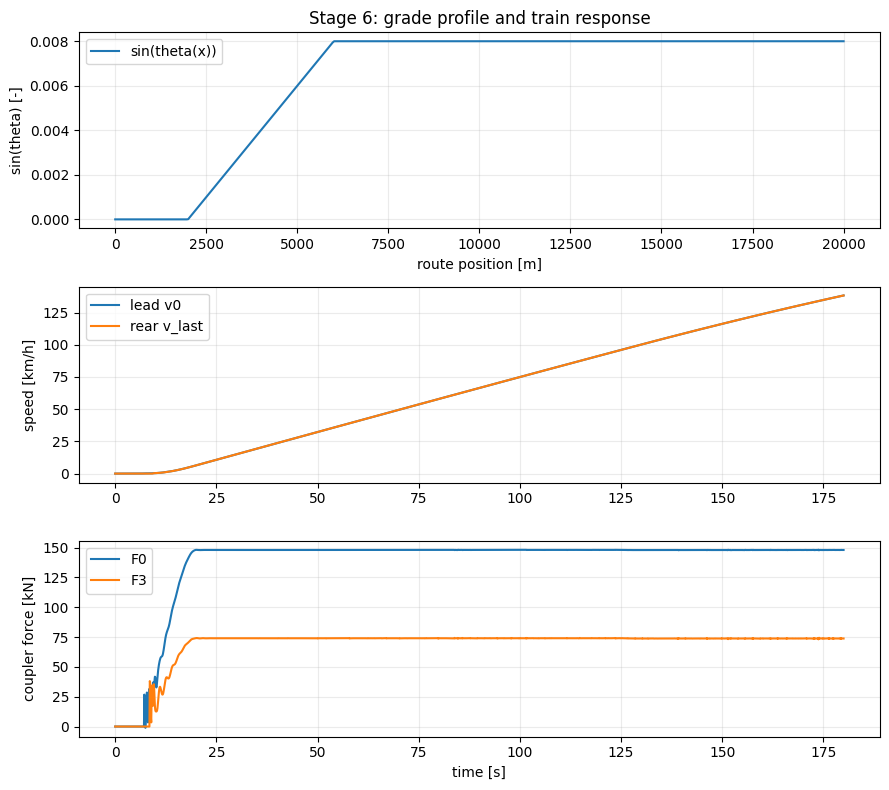

In [13]:
# Piecewise route: flat, mild climb, then flat; optional curvature in middle
s_nodes = np.array([0.0, 2000.0, 6000.0, 20_000.0])
sin_th = np.array([0.0, 0.0, 0.008, 0.008])
kap_nodes = np.array([0.0, 0.0, 1.0 / 800.0, 1.0 / 800.0])

route_hilly = RouteProfile(s_nodes_m=s_nodes, sin_theta_nodes=sin_th, kappa_nodes=kap_nodes)

xg = np.linspace(s_nodes[0], s_nodes[-1], 500)
sin_plot = np.array([route_hilly.sin_theta_at(float(xx)) for xx in xg])

x0_g = np.array([500.0 - i * cpl_N[0].L0_m for i in range(N)], dtype=float)
y0_g = pack_y0(x0_g, np.zeros(N, dtype=float))

sol6 = solve_ivp(
    fun=lambda t, y: train_rhs_n(
        t, y, veh_N, cpl_N, route_hilly, F_trac_lead_only, F_brk_zero, k_curv_scale=2e-4
    ),
    t_span=(0.0, 180.0),
    y0=y0_g,
    t_eval=np.linspace(0.0, 180.0, 2001),
    rtol=1e-6,
    atol=1e-8,
)
assert sol6.success, sol6.message
Vn6 = sol6.y[N : 2 * N]

Fhist6 = np.zeros((N - 1, sol6.t.size))
for k in range(sol6.t.size):
    x = sol6.y[0:N, k]
    v = sol6.y[N : 2 * N, k]
    for j in range(N - 1):
        c = cpl_N[j]
        dlt = (x[j] - x[j + 1]) - c.L0_m
        ddv = v[j] - v[j + 1]
        Fhist6[j, k] = coupler_force_slack_asymmetric(
            np.array([dlt]),
            np.array([ddv]),
            c.slack_half_m,
            c.k_draft,
            c.c_draft,
            c.k_buff,
            c.c_buff,
        )[0]

fig, ax = plt.subplots(3, 1, figsize=(9, 8))
ax[1].sharex(ax[2])
ax[0].plot(xg, sin_plot, label="sin(theta(x))")
ax[0].set_ylabel("sin(theta) [-]")
ax[0].set_xlabel("route position [m]")
ax[0].set_title("Stage 6: grade profile and train response")
ax[0].legend()

ax[1].plot(sol6.t, Vn6[0] * 3.6, label="lead v0")
ax[1].plot(sol6.t, Vn6[-1] * 3.6, label="rear v_last")
ax[1].set_ylabel("speed [km/h]")
ax[1].legend()

ax[2].plot(sol6.t, Fhist6[0] / 1e3, label="F0")
ax[2].plot(sol6.t, Fhist6[N // 2] / 1e3, label=f"F{N//2}")
ax[2].set_ylabel("coupler force [kN]")
ax[2].set_xlabel("time [s]")
ax[2].legend()
plt.tight_layout()
save_ltd_figure(fig, "stage06_grade_profile_lead_rear_speeds_coupler_forces")
plt.show()



#### Interpretation (Stage 6)

Because each $x_i$ differs slightly, **grade and curvature** evaluate at **different** track locations: the head might climb while the tail is still on the flat. You should see **diverging speeds** and **coupler cycles** compared to the flat-route baseline. The curvature proxy is **not** a standard AAR formula—treat `k_curv_scale` as a tuning knob for qualitative behavior.

## Stage 7 — Brake buildup and traction / power limiting

Real **actuators** do not deliver force instantly. A simple first-order lag:

$$
\dot{z}_{\mathrm{brk},i} = \frac{u_{\mathrm{brk},i}(t) - z_{\mathrm{brk},i}}{\tau_b}, \qquad
\dot{z}_{\mathrm{trac},i} = \frac{u_{\mathrm{trac},i}(t) - z_{\mathrm{trac},i}}{\tau_t}.
$$

Use **achieved** brake force $F_{\mathrm{brk},i}=z_{\mathrm{brk},i}$ and **limited** traction

$$
F_{\mathrm{trac},i} = \min\!\left(z_{\mathrm{trac},i},\,\frac{P_{\max}}{\max(|v_i|,\varepsilon)}\right)
$$

on powered vehicles (illustrative continuous-power cap).

**Extended state (documented):**

$$
\mathbf{y}=[x_0,\ldots,x_{N-1},\,v_0,\ldots,v_{N-1},\,z_{\mathrm{brk},0},\ldots,z_{\mathrm{brk},N-1},\,z_{\mathrm{trac},0},\ldots,z_{\mathrm{trac},N-1}]^T\in\mathbb{R}^{4N}.
$$

For unpowered vehicles, keep $u_{\mathrm{trac},i}=0$ so $z_{\mathrm{trac},i}\to 0$.

### What this means physically

Smoother transients; less “infinite jerk” than step force commands.

### Next extension

High-fidelity discussion (Stage 8) and API refactor (Stage 9).


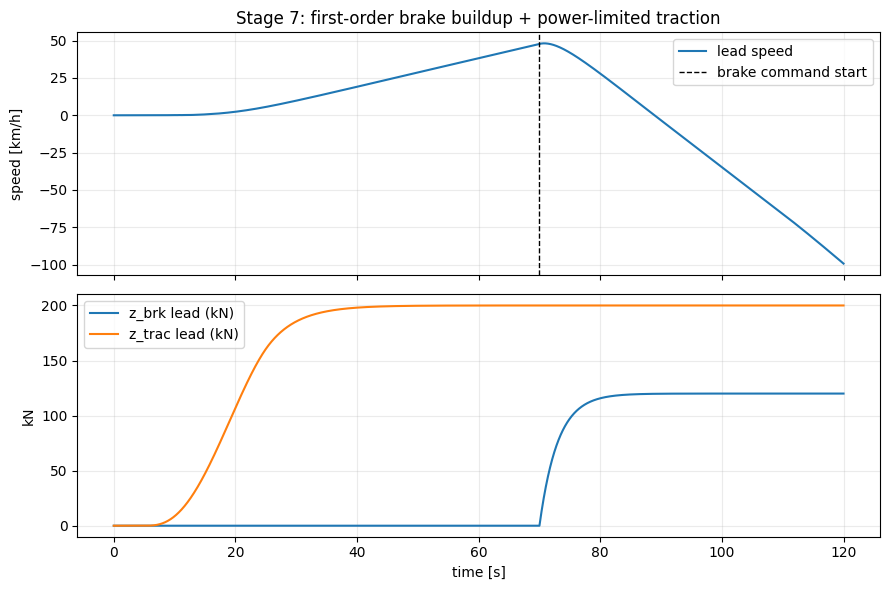

In [ ]:
TAU_BRK_S = 3.0
TAU_TRAC_S = 5.0
P_MAX_W = 3.5e6  # illustrative continuous power cap [W]
V_EPS = 1.0


def train_rhs_extended(
    t: float,
    y: np.ndarray,
    vehicles: Sequence[VehicleParameters],
    couplers: Sequence[CouplerParameters],
    route: RouteProfile,
    u_trac_cmd: Callable[[float, int], float],
    u_brk_cmd: Callable[[float, int], float],
    k_curv_scale: float,
    tau_brk: float,
    tau_trac: float,
    p_max_w: float,
) -> np.ndarray:
    N = len(vehicles)
    x = y[0:N]
    v = y[N : 2 * N]
    z_brk = y[2 * N : 3 * N]
    z_trac = y[3 * N : 4 * N]
    dx = v
    F_couple = np.zeros(N - 1, dtype=float)
    for j in range(N - 1):
        c = couplers[j]
        dlt = (x[j] - x[j + 1]) - c.L0_m
        ddv = v[j] - v[j + 1]
        F_couple[j] = float(
            coupler_force_slack_asymmetric(
                np.array([dlt]),
                np.array([ddv]),
                c.slack_half_m,
                c.k_draft,
                c.c_draft,
                c.k_buff,
                c.c_buff,
            )[0]
        )
    dv = np.zeros(N, dtype=float)
    dz_brk = np.zeros(N, dtype=float)
    dz_trac = np.zeros(N, dtype=float)
    for i in range(N):
        vp = vehicles[i]
        ut = u_trac_cmd(t, i) if vp.can_traction else 0.0
        ub = u_brk_cmd(t, i)
        dz_trac[i] = (float(ut) - float(z_trac[i])) / tau_trac
        dz_brk[i] = (float(ub) - float(z_brk[i])) / tau_brk
        Fi_in = F_couple[i - 1] if i > 0 else 0.0
        Fi_out = F_couple[i] if i < N - 1 else 0.0
        R = float(davis_resistance_longitudinal(v[i], vp.davis_A, vp.davis_B, vp.davis_C))
        G = grade_force(vp.mass_kg, float(x[i]), route.sin_theta_at)
        C = curvature_force_longitudinal(vp.mass_kg, float(v[i]), float(x[i]), route, k_curv_scale)
        zt = float(max(z_trac[i], 0.0))
        zb = float(max(z_brk[i], 0.0))
        F_tr = 0.0
        if vp.can_traction:
            F_tr = min(zt, p_max_w / max(abs(float(v[i])), V_EPS))
        F_br = min(zb, vp.F_brk_max_N)
        dv[i] = (F_tr - F_br - R - G - C + Fi_in - Fi_out) / vp.mass_kg
    return np.concatenate([dx, dv, dz_brk, dz_trac])


T_BRK = 70.0
BRAKE_CMD = 120_000.0


def u_trac_stage7(t: float, i: int) -> float:
    return traction_ramp(t, t0=5.0, t1=25.0, F_max=200_000.0) if i == 0 else 0.0


def u_brk_stage7(t: float, i: int) -> float:
    return BRAKE_CMD if (t > T_BRK) else 0.0


z0 = np.zeros(N, dtype=float)
y0_ext = np.concatenate([x0_train, v0_train, z0, z0])

sol7 = solve_ivp(
    fun=lambda t, y: train_rhs_extended(
        t,
        y,
        veh_N,
        cpl_N,
        route_flat,
        u_trac_stage7,
        u_brk_stage7,
        k_curv_scale=0.0,
        tau_brk=TAU_BRK_S,
        tau_trac=TAU_TRAC_S,
        p_max_w=P_MAX_W,
    ),
    t_span=(0.0, 120.0),
    y0=y0_ext,
    t_eval=np.linspace(0.0, 120.0, 2401),
    rtol=1e-6,
    atol=1e-8,
)
assert sol7.success, sol7.message
V7 = sol7.y[N : 2 * N]

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].plot(sol7.t, V7[0] * 3.6, label="lead speed")
ax[0].axvline(T_BRK, color="k", ls="--", lw=1, label="brake command start")
ax[0].set_ylabel("speed [km/h]")
ax[0].set_title("Stage 7: first-order brake buildup + power-limited traction")
ax[0].legend()

ax[1].plot(sol7.t, sol7.y[2 * N, :] / 1e3, label="z_brk lead (kN)")
ax[1].plot(sol7.t, sol7.y[3 * N, :] / 1e3, label="z_trac lead (kN)")
ax[1].set_ylabel("kN")
ax[1].set_xlabel("time [s]")
ax[1].legend()
plt.tight_layout()
save_ltd_figure(fig, "stage07_brake_buildup_power_limited_traction_states")
plt.show()



#### Interpretation (Stage 7)

The **lagged brake state** `z_brk` smooths what would otherwise be a step in braking force. **Power limiting** caps traction at low speed so the locomotive cannot exceed `P_max` (continuous-power idealization). Compare to Stage 5 on flat track: transients should look less “sharp” in traction, and braking onset should ramp in over a few seconds.

## Stage 8 — What “high fidelity” still adds

This notebook implements a **transparent, intermediate** longitudinal simulator core: point masses, nonlinear slack couplers, Davis resistance, interpolated route grade/curvature, and simple actuator lags.

**Extensions not fully implemented here (typical “high fidelity” research items):**

- **Draft gear hysteresis:** Bouc–Wen, Prandtl–Ishlinskii, or phenomenological load–unload loops tied to measured quasistatic curves.  
- **Brake pipe / air brake dynamics:** pressure-wave propagation, valve logic, cylinder fill/empty, asymmetric application/release.  
- **Distributed power:** multiple powered axles with independent adhesion limits and control allocation.  
- **Wheel–rail adhesion / slip:** creep curves, spin dynamics, anti-slip control interactions.  
- **Stochastic parameters:** mass, resistance, coupler slack, and effective friction as uncertain inputs (Monte Carlo / robustness studies).  
- **Calibration:** fit parameters to field test or high-rate coupler / in-train force data.

### Model hierarchy (conceptual)

- **Low fidelity:** single equivalent mass, algebraic resistance, no coupler elasticity.  
- **Intermediate:** multi-body, nonlinear couplers, route forces, simple actuators (this notebook).  
- **High fidelity:** hysteretic couplers + pneumatic braking + adhesion + validated parameters + possibly cosimulation with detailed traction control.

### Implementation notes

Treat Stage 8 as a **roadmap**: each bullet is a module boundary you can add while keeping the same state/force interface.

### Next extension

Package the working code behind a small API (Stage 9).


## Stage 9 — Refactor toward a reusable simulator

Below we collect a **compact API** still readable in-notebook:

- `simulate_train(...)`: integrates and reconstructs coupler force history.  
- `plot_train_results(...)`: standard speed + coupler plots.

Later, move these functions (and dataclasses) into a `.py` module such as `ltd_sim/core.py` while keeping notebooks for teaching.

### Next extension

Unit tests for RHS sign consistency; calibration workflows; coupling to ML (PyTorch) as a differentiable or hybrid wrapper.


In [ ]:
@dataclass
class TrainSimulationConfig:
    vehicles: List[VehicleParameters]
    couplers: List[CouplerParameters]
    route: RouteProfile
    t_span: Tuple[float, float]
    t_eval: Optional[np.ndarray] = None
    k_curv_scale: float = 0.0
    rtol: float = 1e-6
    atol: float = 1e-8
    method: str = "RK45"


def simulate_train(
    y0: np.ndarray,
    rhs: Callable[[float, np.ndarray], np.ndarray],
    cfg: TrainSimulationConfig,
) -> Dict[str, Any]:
    """Integrate generic RHS(y in R^{n_state}) and post-process coupler forces for N-vehicle trains.

    If state is 2N (basic train), coupler history is computed from positions/velocities.
    If state is 4N (extended), first 2N entries are still x,v.
    """
    sol = solve_ivp(
        fun=rhs,
        t_span=cfg.t_span,
        y0=y0,
        t_eval=cfg.t_eval,
        rtol=cfg.rtol,
        atol=cfg.atol,
        method=cfg.method,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    N = len(cfg.vehicles)
    n_state = sol.y.shape[0]
    if n_state < 2 * N:
        raise ValueError("State too small for vehicle count")
    Xh = sol.y[0:N, :]
    Vh = sol.y[N : 2 * N, :]
    Fhist = np.zeros((N - 1, sol.t.size))
    for k in range(sol.t.size):
        x = Xh[:, k]
        v = Vh[:, k]
        for j in range(N - 1):
            c = cfg.couplers[j]
            dlt = (x[j] - x[j + 1]) - c.L0_m
            ddv = v[j] - v[j + 1]
            Fhist[j, k] = coupler_force_slack_asymmetric(
                np.array([dlt]),
                np.array([ddv]),
                c.slack_half_m,
                c.k_draft,
                c.c_draft,
                c.k_buff,
                c.c_buff,
            )[0]
    return {"sol": sol, "F_coupler": Fhist, "N": N}


def plot_train_results(
    res: Dict[str, Any],
    speed_indices: Sequence[int],
    coupler_indices: Sequence[int],
    title: str = "",
    figure_save_stem: Optional[str] = None,
) -> None:
    sol = res["sol"]
    Fhist = res["F_coupler"]
    N = res["N"]
    V = sol.y[N : 2 * N, :]
    fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    for i in speed_indices:
        ax[0].plot(sol.t, V[i] * 3.6, label=f"v{i}")
    ax[0].set_ylabel("speed [km/h]")
    ax[0].set_title(title or "Train simulation")
    ax[0].legend()
    for j in coupler_indices:
        ax[1].plot(sol.t, Fhist[j] / 1e3, label=f"F{j}")
    ax[1].set_ylabel("coupler force [kN]")
    ax[1].set_xlabel("time [s]")
    ax[1].legend()
    plt.tight_layout()
    if figure_save_stem:
        save_ltd_figure(fig, figure_save_stem)
    plt.show()


cfg_demo = TrainSimulationConfig(
    vehicles=veh_N,
    couplers=cpl_N,
    route=route_flat,
    t_span=(0.0, 100.0),
    t_eval=np.linspace(0.0, 100.0, 1501),
)

res_demo = simulate_train(
    y0_n,
    lambda t, y: train_rhs_n(
        t, y, cfg_demo.vehicles, cfg_demo.couplers, cfg_demo.route, F_trac_lead_only, F_brk_zero, cfg_demo.k_curv_scale
    ),
    cfg_demo,
)
plot_train_results(
    res_demo,
    speed_indices=[0, N // 2, N - 1],
    coupler_indices=[0, N // 3],
    title="Stage 9: API demo on flat route",
    figure_save_stem="stage09_api_demo_flat_route_speeds_coupler_forces",
)



## Summary

You built a **longitudinal train dynamics** model from a single locomotive to an $N$-body system with **nonlinear slack couplers**, **Davis resistance**, **route-based grade and curvature**, and **simple actuator dynamics**, integrated with `solve_ivp`.

### Suggested next steps

- **Parameter calibration** against literature curves or measured consist data.  
- **Validation** against published LTD benchmarks or your own field tests.  
- **Probabilistic perturbations** on masses, resistance, and slack for robustness studies.  
- **PyTorch integration** (differentiable surrogates, learning residual forces, or hybrid physics–ML).  
- **Hybrid framework:** use this simulator as the **physics core** with ML for unknown disturbances, wear, or sub-grid phenomena.
